In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [14]:
models ={
    "Logistic Regression":LogisticRegression(),
    "Desicion Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier()
}

In [15]:
df = pd.read_csv('stream_pulse_customer_data.csv')

print(df.head())

  CustomerID  Age  TenureMonths  MonthlyFee  TotalSpent  PlanType Region  \
0  SP-000001   23            50       11.49      595.60     Basic   East   
1  SP-000002   62             7       11.16       80.47     Basic   East   
2  SP-000003   55            54       16.07      888.27  Standard  North   
3  SP-000004   43             7       16.27      179.45     Basic   West   
4  SP-000005   42             3       10.85       98.80     Basic  South   

   PaymentMethod  DeviceCount  StreamingHours  SupportTickets AutoPay  \
0         PayPal            1            10.4               0     Yes   
1         PayPal            1            68.7               1     Yes   
2  Mobile Wallet            1            28.4               2     Yes   
3    Credit Card            4            64.4               1      No   
4     Debit Card            5            29.2               0     Yes   

  FamilyPlan Churn  
0        Yes    No  
1         No   Yes  
2        Yes    No  
3         No    No  

In [16]:
#delete un important columns
df=df.drop('CustomerID',axis=1)

In [18]:
le=LabelEncoder()
binary_cols=['AutoPay','FamilyPlan','Churn']
for col in binary_cols:
    df[col]=le.fit_transform(df[col])

In [19]:
df=pd.get_dummies(df,columns=['PlanType','Region','PaymentMethod'])

In [20]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [21]:
x_train ,x_test,y_train ,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [27]:
print("first models testing")
best=0
best_m_name=""
for name , model in models.items():
    x_tr=x_train_scaled if name == "Logistic Regression" else x_train
    x_ts = x_test_scaled if name == "Logistic Regression" else x_test
    model.fit (x_tr , y_train)
    y_pred = model.predict(x_ts)
    score = f1_score(y_test,y_pred)
    print(f"{name} F1-score : {score:.4f}")
    if score>best:
        best=score
        best_m_name=name

first models testing
Logistic Regression F1-score : 0.0000
Decision Tree F1-score : 0.2609
Random Forest F1-score : 0.0000


In [28]:
param_grid = {
'n_estimators': [50, 100],
'max_depth': [None, 10, 20],
'min_samples_split': [2, 5]
}

In [32]:
grid_search = GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid,
cv=5,
scoring='f1'
)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='f1')

In [33]:
final_model = grid_search.best_estimator_
print(f"best settings : {grid_search.best_params_}")

best settings : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}


In [35]:
y_pred_final = final_model.predict(x_test)

In [36]:
print("\n final report")
print(classification_report(y_test, y_pred_final))


 final report
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       410
           1       0.00      0.00      0.00        90

    accuracy                           0.82       500
   macro avg       0.41      0.50      0.45       500
weighted avg       0.67      0.82      0.74       500



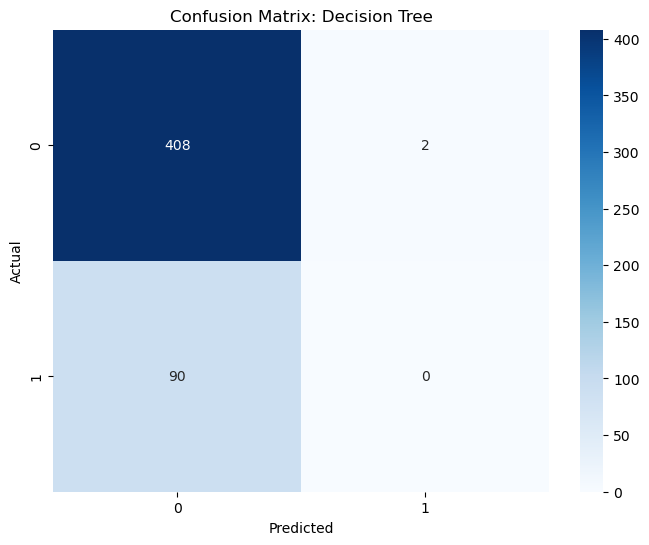

In [38]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_m_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png') 
plt.show()

In [47]:
y_probs = final_model.predict_proba(x_test)[:, 1]

new_threshold = 0.3
y_pred_new = (y_probs >= new_threshold).astype(int)


print(f"--- report after editing {new_threshold} ---")
print(classification_report(y_test, y_pred_new))

--- report after editing 0.3 ---
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       410
           1       0.25      0.30      0.27        90

    accuracy                           0.71       500
   macro avg       0.54      0.55      0.55       500
weighted avg       0.73      0.71      0.72       500



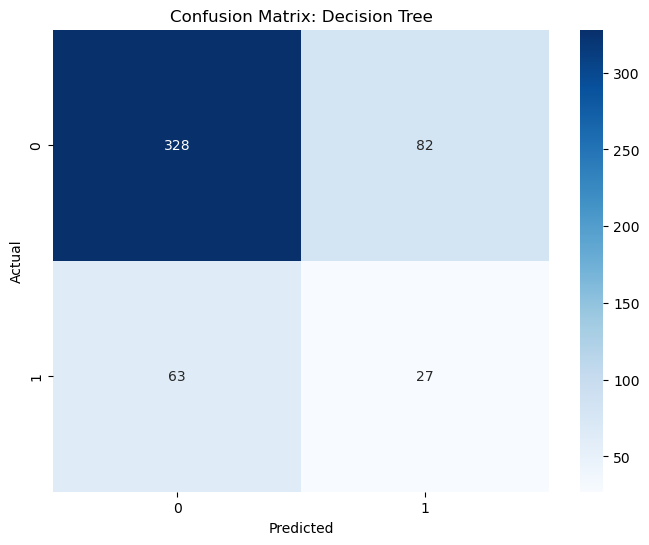

In [48]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_new)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_m_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png') 
plt.show()